# Open-Hole Porosity Packet User Walkthrough

Build an open-hole porosity packet from a public LAS file one stage at a time, from reusable template to gas-crossover fill and the final two-window packet.

## Who This Notebook Is For

A geologist or petrophysicist who wants to adapt a compact open-hole interpretation packet without having to learn the `wellplot` YAML layout structure first.

## What You Will Learn

- how to inspect the source data and confirm which channels and header fields are available
- how to separate reusable template work from well-specific logfile work
- how to validate YAML and template wiring with `load_logfile(...)`
- how to render a packet with `render_from_logfile(...)` after each major edit
- how to add headings, remarks, tracks, curve bindings, fills, and extra sections in a controlled order

Prerequisites:

- `pip install "wellplot[las,notebook]"`
- run the notebook from a checkout of this repository so the `examples/` files and sample data are available

## The Three `wellplot` Functions That Matter In This Workflow

- `load_datasets_for_logfile(...)` to inspect the source file and list the channels you can actually plot
- `load_logfile(...)` to validate the YAML and the template resolution before you render
- `render_from_logfile(...)` to produce the packet PDF once the YAML is ready

## How To Read This Notebook

- each stage writes a real YAML file under `workspace/tutorials/`
- each render cell validates and renders that stage exactly like a real user workflow
- the inline images are visual checkpoints so you can compare your result with the expected packet state


In [1]:
from pathlib import Path

try:
    import wellplot
except ImportError as exc:
    raise RuntimeError(
        "Install the published 'wellplot' package in the active environment "
        "before running this notebook."
    ) from exc

cwd = Path.cwd().resolve()
REPO_ROOT = next((path for path in (cwd, *cwd.parents) if (path / "examples").exists()), None)
if REPO_ROOT is None:
    raise RuntimeError(
        "Run this notebook from a checkout of the wellplot repository so the "
        "example files and sample data are available."
    )

package_dir = REPO_ROOT / "examples" / "production" / "forge16b_porosity_example"
example_logfile = package_dir / "full_reconstruction.log.yaml"
tutorial_dir = REPO_ROOT / "workspace" / "tutorials" / "forge16b_porosity_example"
render_dir = tutorial_dir / "renders"
tutorial_dir.mkdir(parents=True, exist_ok=True)
render_dir.mkdir(parents=True, exist_ok=True)

print("wellplot version:", wellplot.__version__)
print("Production example:", example_logfile.relative_to(REPO_ROOT))
print("Tutorial workspace:", tutorial_dir.relative_to(REPO_ROOT))
print("Render output folder:", render_dir.relative_to(REPO_ROOT))


wellplot version: 0.1.0
Production example: examples/production/forge16b_porosity_example/full_reconstruction.log.yaml
Tutorial workspace: workspace/tutorials/forge16b_porosity_example
Render output folder: workspace/tutorials/forge16b_porosity_example/renders


## Inspect The Source Data Before You Design The Plot

A practical workflow starts by confirming two things:

- which channels are available in the source file
- which metadata fields are good enough to populate the heading

Use the shipped `forge16b_porosity_example` example as the inspection source, then copy the same pattern to your own well.


In [2]:
from wellplot import load_datasets_for_logfile, load_logfile

spec = load_logfile(example_logfile)
datasets_by_section, _source_paths = load_datasets_for_logfile(spec, base_dir=example_logfile.parent)
dataset = datasets_by_section["upper_review"]

wanted_channels = ['GR', 'SP', 'ILD', 'ILM', 'MSFL', 'NPHI', 'RHOB', 'PEF', 'DRHO']
available_channels = [channel for channel in wanted_channels if channel in dataset.channels]
print("Sections available:", ", ".join(datasets_by_section))
print("Channels used in this tutorial:", ", ".join(available_channels))
print("Header fields available from the source data:")
for key in ['COMP', 'WELL', 'FLD', 'LOC', 'UWI', 'DATE']:
    print(f"  {key}: {dataset.well_metadata.get(key)}")


Sections available: upper_review, lower_review
Channels used in this tutorial: GR, SP, ILD, ILM, MSFL, NPHI, RHOB, PEF, DRHO
Header fields available from the source data:
  COMP: SHELL
  WELL: 30/23a-3
  FLD: WILDCAT
  LOC: NORTH SEA
  UWI: 8117
  DATE: SEP-OCT-1985


## Create The Reusable Template First

This file should hold the decisions that you expect to reuse for many wells.

- Put page size, depth scale, heading fields, default style, and tail behavior in the template because you will usually reuse those decisions across many wells.
- Keep the logfile for the parts that change per well or per packet: data source paths, depth windows, remarks, tracks, curve bindings, and fills.
- Start with a small reusable template. Add only the heading fields and style defaults you need before you copy the packet to another well.

Write the template once, then keep the later stage files focused on data sources, sections, tracks, and bindings.


In [3]:
template_path = tutorial_dir / "base.template.yaml"
template_text = '''
render:
  backend: matplotlib
  output_path: ./renders/tutorial_template_placeholder.pdf
  dpi: 180
  matplotlib:
    style:
      report:
        summary_label_fontsize: 8.0
        summary_value_fontsize: 10.5
        provider_fontsize: 16.0
        service_fontsize: 8.0
        tail_service_fontsize: 8.0
        field_label_fontsize: 7.0
        field_value_fontsize: 7.8
        detail_header_fontsize: 9.0
        detail_label_fontsize: 6.4
        detail_value_fontsize: 6.4
        tail_frame_y: 0.74
        tail_frame_height: 0.22
      section_title:
        background_color: '#0d3fb3'
        border_mode: box
        border_color: '#0d3fb3'
        border_linewidth: 0.8
        padding_left: 0.03
        padding_right: 0.03
        title_align: center
        subtitle_align: center
        title_fontsize: 11.0
        subtitle_fontsize: 6.6
        title_color: '#ffffff'
        subtitle_color: '#eaf0ff'
        title_y: 0.68
        subtitle_y: 0.22
      track_header:
        background_color: '#eef2f8'
      track:
        x_tick_labelsize: 6.0
      grid:
        depth_major_linewidth: 0.65
document:
  depth_range:
  - 8400
  - 10200
  page:
    size: A4
    orientation: portrait
    continuous: false
    bottom_track_header_enabled: true
    margin_left_mm: 0
    margin_right_mm: 8
    margin_top_mm: 0
    margin_bottom_mm: 0
    track_gap_mm: 0
    header_height_mm: 0
    track_header_height_mm: 30
    footer_height_mm: 0
  depth:
    unit: ft
    scale: 240
    major_step: 10
    minor_step: 2
  layout:
    heading:
      enabled: true
      provider_name: Company
      general_fields:
      - key: company
        label: Company
        source_key: COMP
      - key: well
        label: Well
        source_key: WELL
      - key: field
        label: Field
        source_key: FLD
      - key: location
        label: Location
        source_key: LOC
      - key: uwi
        label: UWI
        source_key: UWI
      - key: logging_date
        label: Logging Date
        source_key: DATE
      - key: scale
        label: Scale
        value: ft 1:240
      service_titles:
      - value: Open Hole Density
        font_size: 15
        auto_adjust: true
        bold: true
        alignment: left
      - value: Neutron Porosity
        font_size: 14
        auto_adjust: true
        alignment: center
      - value: Resistivity Review
        font_size: 13
        auto_adjust: true
        alignment: right
      detail:
        kind: open_hole
        title: Open Hole Metadata
        rows:
        - label: Project
          values:
          - source_key: PROJ
          - ''
        - label: Service Company
          values:
          - source_key: SRVC
          - ''
        - label: Logging Measured From
          values:
          - source_key: LMF
          - ''
        - label: Permanent Datum
          values:
          - source_key: PDAT
          - ''
    remarks:
    - title: Public Data and IP Notice
      lines:
      - This tutorial uses publicly available or repository-provided demonstration
        data intended for educational use.
      - Rendered layouts are independent reproductions generated by wellplot, not
        vendor-authored originals or official service-company deliverables.
      alignment: left
    log_sections: []
    tail:
      enabled: true
  bindings:
    on_missing: skip
    channels: []
'''
template_path.write_text(template_text)

print("Wrote:", template_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/forge16b_porosity_example/base.template.yaml


## Step 1. Build the smallest useful packet

Start with one depth window, one overview track, and one first curve so you can prove the template, heading, remarks, and depth axis all work together.

What this step teaches:

- The template supplies the heading and page defaults.
- The logfile adds one section, one data source, and one first binding.
- The depth track defines the vertical layout axis even though no curve is bound to it.


In [4]:
step_1_first_packet_logfile_path = tutorial_dir / "step_1_first_packet.log.yaml"
step_1_first_packet_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: Porosity tutorial step 1 - first packet
render:
  output_path: ./renders/step_1_first_packet.pdf
document:
  layout:
    remarks:
    - title: What this first packet proves
      lines:
      - The template can resolve heading fields from the LAS header.
      - A single section is enough to prove page geometry, depth scale, and one first
        curve.
      alignment: left
    log_sections:
    - id: upper_review
      title: Upper Open-Hole Review
      subtitle: 30-23a-3 8117_d.las
      depth_range:
      - 8400
      - 9300
      data:
        source_path: ../../data/30-23a-3 8117_d.las
        source_format: las
      tracks:
      - id: gr_sp
        title: ''
        kind: normal
        width_mm: 38
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 20
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
  bindings:
    channels:
    - section: upper_review
      channel: GR
      track_id: gr_sp
      kind: curve
      label: Gamma Ray (GR)
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
      fill:
        kind: to_lower_limit
        label: Gamma Fill
        color: '#8fd19e'
        alpha: 0.22
'''
step_1_first_packet_logfile_path.write_text(step_1_first_packet_logfile_text)

print("Wrote:", step_1_first_packet_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/forge16b_porosity_example/step_1_first_packet.log.yaml


Validated: Porosity tutorial step 1 - first packet
Pages created: 7
PDF written to: workspace/tutorials/forge16b_porosity_example/renders/step_1_first_packet.pdf


### Opening page after step 1

The heading resolves from LAS metadata and the remarks explain the packet scope.

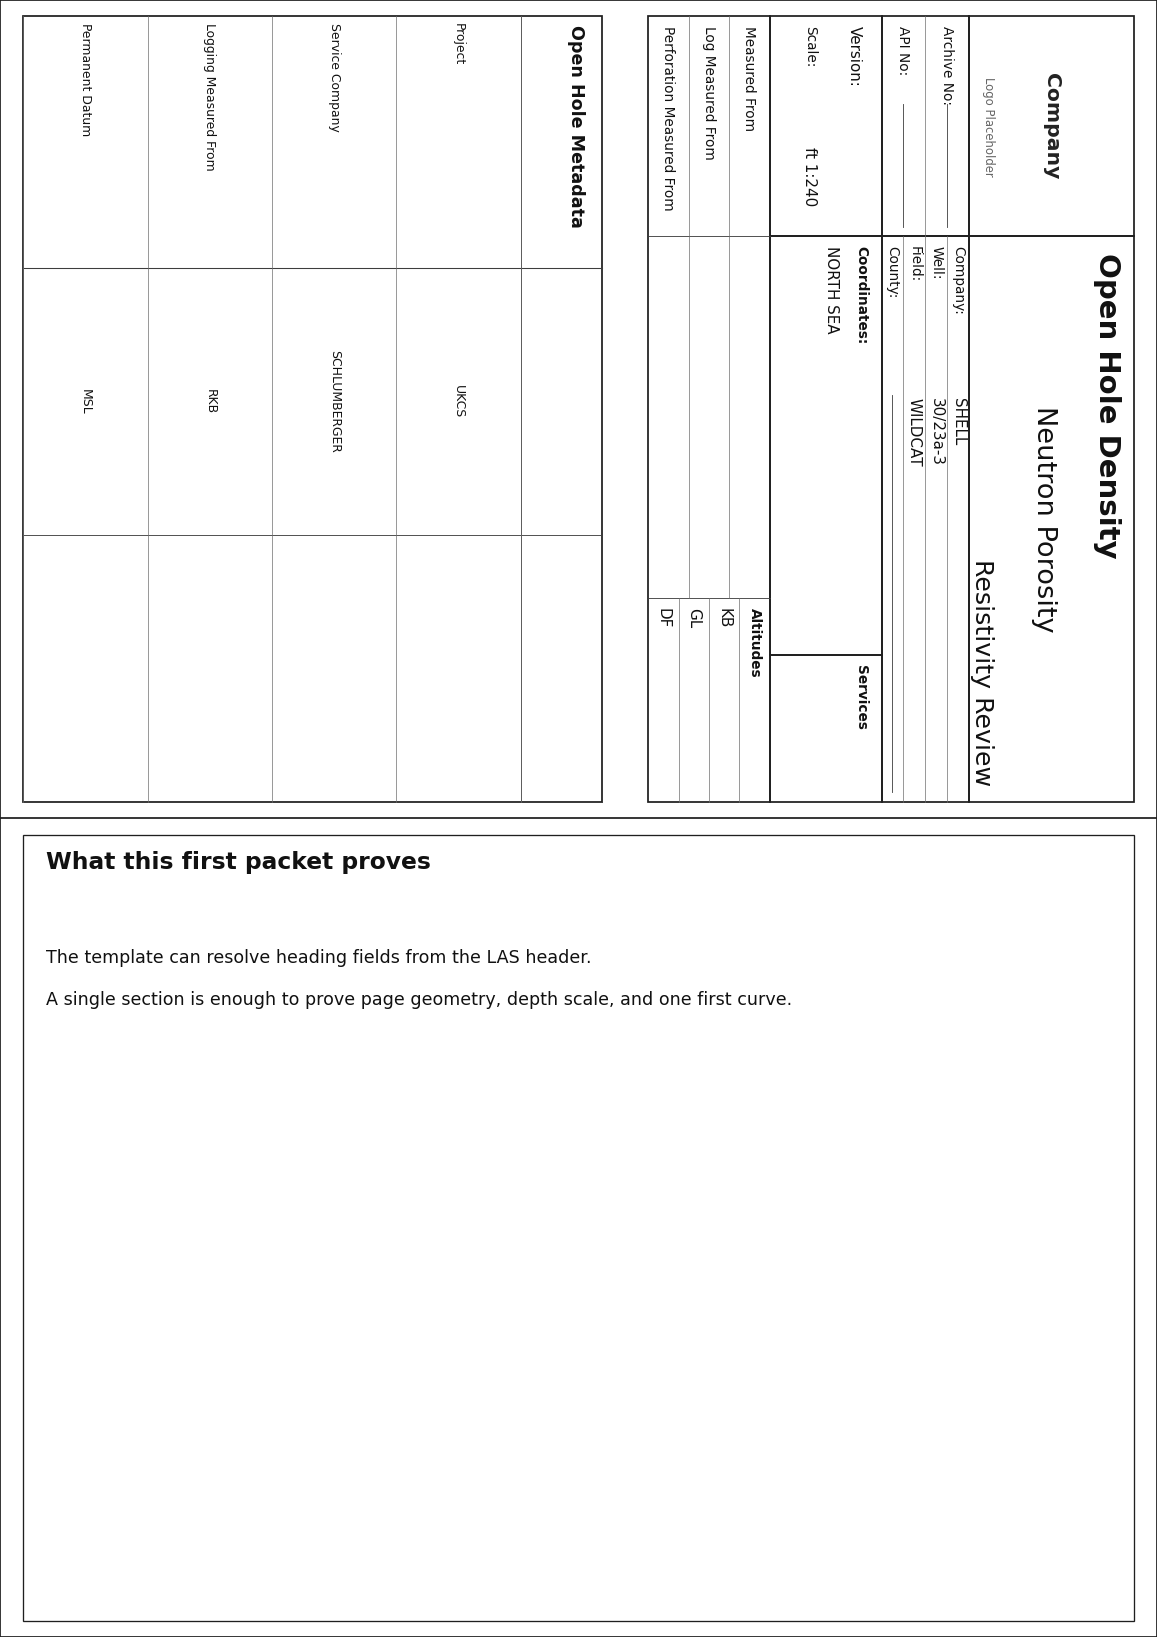

### First strip after step 1

A single GR curve is enough to confirm the depth axis, grid, and track header are behaving correctly.

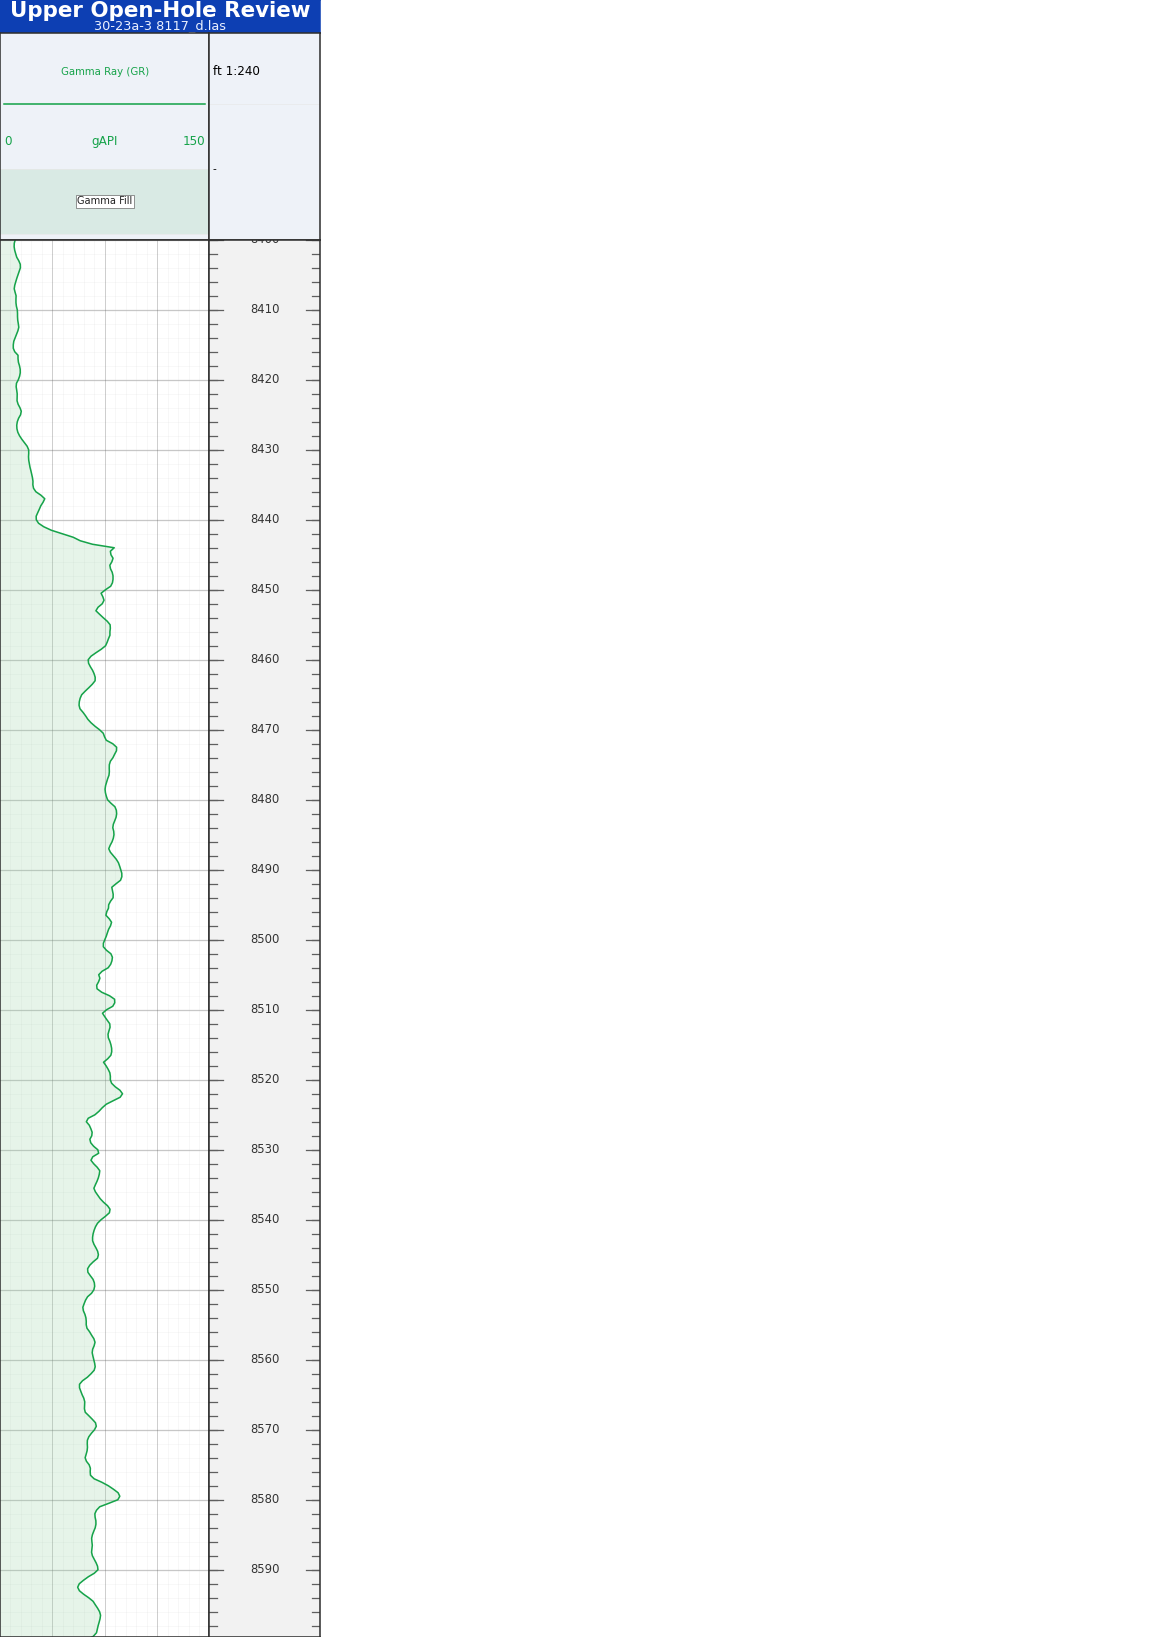

In [5]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_1_first_packet_logfile_path)
result = render_from_logfile(step_1_first_packet_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## Step 2. Add the resistivity review track

Once the first strip is stable, add the resistivity track and bind the deep, medium, and flushed-zone curves with log scaling.

What this step teaches:

- One section can host multiple tracks that share the same source file and depth range.
- Each curve binding chooses its own style and scale even when several curves share the same track.
- This is the right point to tune curve labels, line styles, and track widths before you add interpretation fills.


In [6]:
step_2_add_resistivity_logfile_path = tutorial_dir / "step_2_add_resistivity.log.yaml"
step_2_add_resistivity_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: Porosity tutorial step 2 - add the resistivity track
render:
  output_path: ./renders/step_2_add_resistivity.pdf
document:
  layout:
    remarks:
    - title: Why the second step matters
      lines:
      - Keep the same section and add more tracks only after the first packet renders
        cleanly.
      - The resistivity track shows how one source file can feed multiple curve overlays
        with different styles and scales.
      alignment: left
    log_sections:
    - id: upper_review
      title: Upper Open-Hole Review
      subtitle: 30-23a-3 8117_d.las
      depth_range:
      - 8400
      - 9300
      data:
        source_path: ../../data/30-23a-3 8117_d.las
        source_format: las
      tracks:
      - id: gr_sp
        title: ''
        kind: normal
        width_mm: 38
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 20
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: resistivity
        title: ''
        kind: normal
        width_mm: 40
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
  bindings:
    channels:
    - section: upper_review
      channel: GR
      track_id: gr_sp
      kind: curve
      label: Gamma Ray (GR)
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
      fill:
        kind: to_lower_limit
        label: Gamma Fill
        color: '#8fd19e'
        alpha: 0.22
    - section: upper_review
      channel: SP
      track_id: gr_sp
      kind: curve
      label: Spontaneous Potential (SP)
      header_display:
        wrap_name: true
      style:
        color: '#8b5e3c'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: -60
        max: 80
    - section: upper_review
      channel: ILD
      track_id: resistivity
      kind: curve
      label: Deep Induction (ILD)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: ILM
      track_id: resistivity
      kind: curve
      label: Medium Induction (ILM)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.7
        line_style: --
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: MSFL
      track_id: resistivity
      kind: curve
      label: Microspherically Focused (MSFL)
      header_display:
        wrap_name: true
      style:
        color: '#c62828'
        line_width: 0.7
        line_style: -.
      scale:
        kind: log
        min: 0.2
        max: 2000
'''
step_2_add_resistivity_logfile_path.write_text(step_2_add_resistivity_logfile_text)

print("Wrote:", step_2_add_resistivity_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/forge16b_porosity_example/step_2_add_resistivity.log.yaml


Validated: Porosity tutorial step 2 - add the resistivity track
Pages created: 7
PDF written to: workspace/tutorials/forge16b_porosity_example/renders/step_2_add_resistivity.pdf


### Upper review after step 2

The packet now shows GR/SP plus deep, medium, and flushed-zone resistivity overlays.

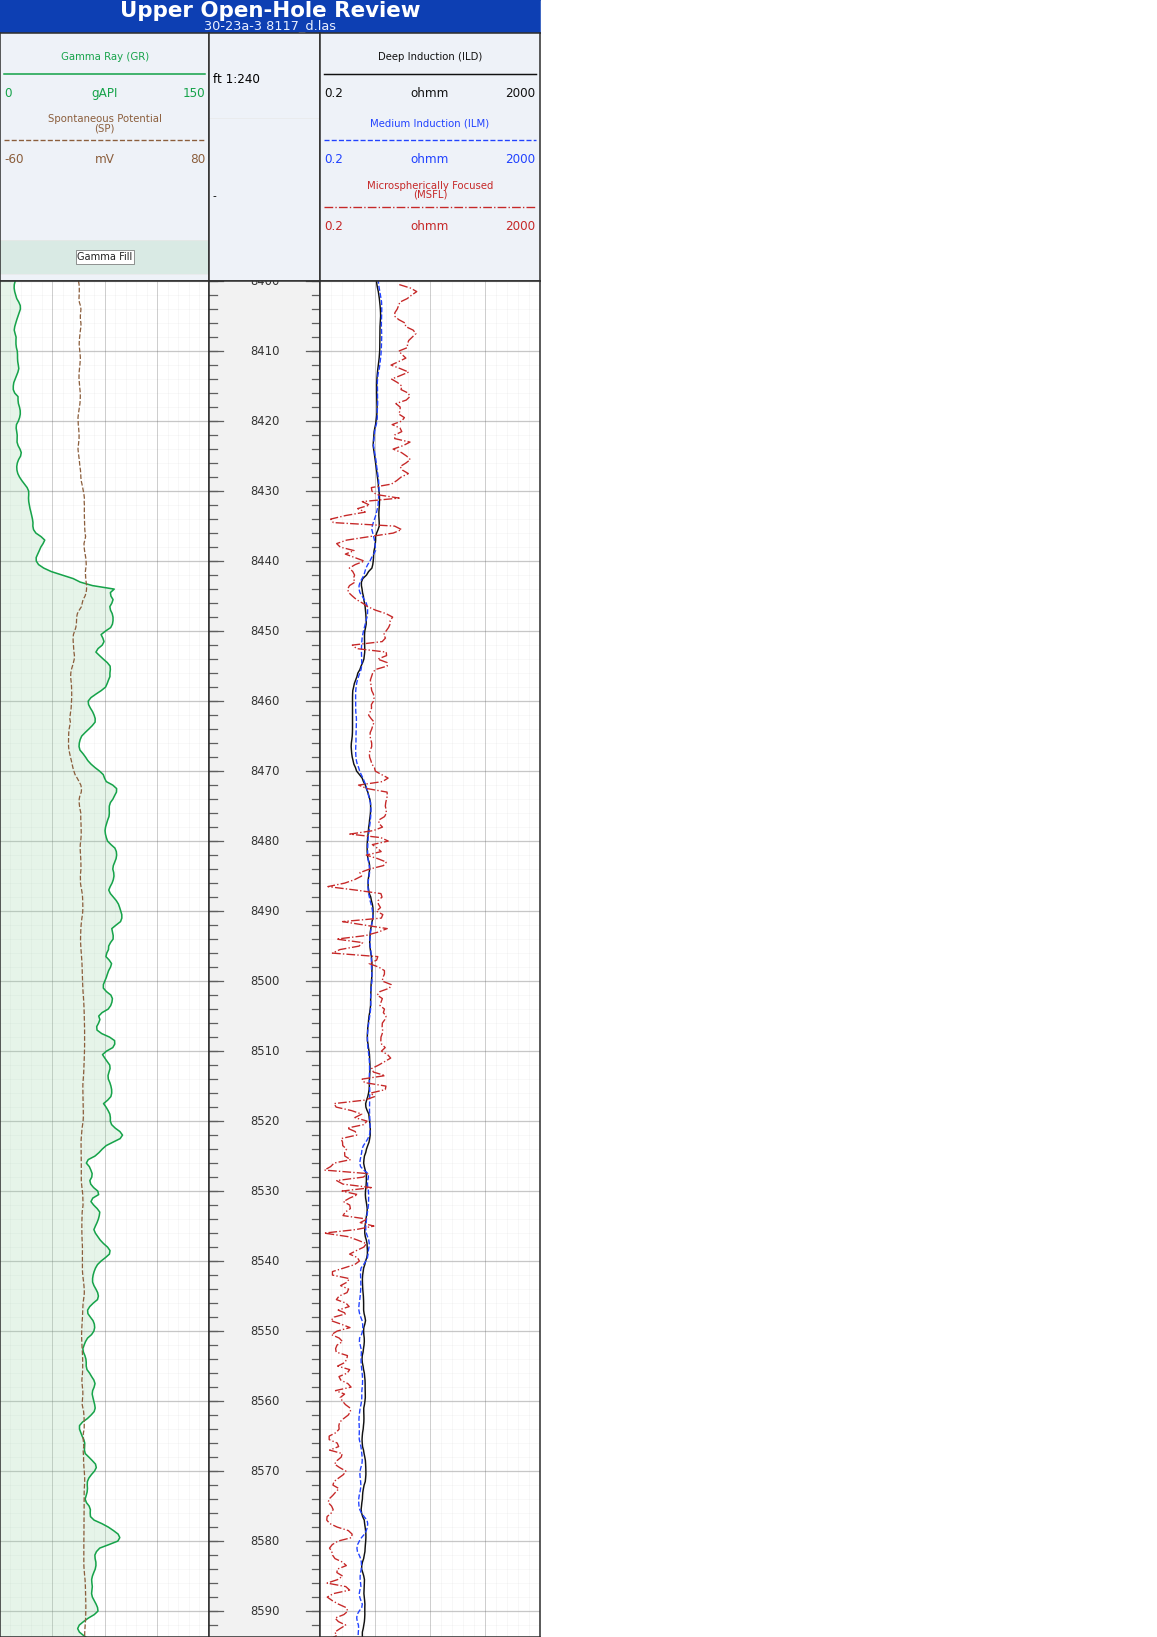

In [7]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_2_add_resistivity_logfile_path)
result = render_from_logfile(step_2_add_resistivity_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## Step 3. Add the porosity track and gas crossover fill

Bind neutron, density, and QC curves, then add the crossover fill so the packet starts carrying porosity interpretation value instead of only presentation structure.

What this step teaches:

- Use ids on related curve bindings when a fill needs to refer to another element.
- The crossover block is what creates the two-sided gas fill in the strip and the matching header indicator.
- Add QC curves such as PEF and DRHO only after the main interpretation pair is already behaving correctly.


In [8]:
step_3_add_porosity_fill_logfile_path = tutorial_dir / "step_3_add_porosity_fill.log.yaml"
step_3_add_porosity_fill_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: Porosity tutorial step 3 - add the porosity interpretation track
render:
  output_path: ./renders/step_3_add_porosity_fill.pdf
document:
  layout:
    remarks:
    - title: Why the porosity track is built last
      lines:
      - The density-neutron track depends on two related curves plus optional QC curves.
      - The gas crossover fill works only after both the neutron and density bindings
        exist and their ids match.
      alignment: left
    log_sections:
    - id: upper_review
      title: Upper Open-Hole Review
      subtitle: 30-23a-3 8117_d.las
      depth_range:
      - 8400
      - 9300
      data:
        source_path: ../../data/30-23a-3 8117_d.las
        source_format: las
      tracks:
      - id: gr_sp
        title: ''
        kind: normal
        width_mm: 38
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 20
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: resistivity
        title: ''
        kind: normal
        width_mm: 40
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: porosity
        title: ''
        kind: normal
        width_mm: 48
        position: 4
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 5
          - kind: divisions
            enabled: false
            reserve_space: false
  bindings:
    channels:
    - section: upper_review
      channel: GR
      track_id: gr_sp
      kind: curve
      label: Gamma Ray (GR)
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
      fill:
        kind: to_lower_limit
        label: Gamma Fill
        color: '#8fd19e'
        alpha: 0.22
    - section: upper_review
      channel: SP
      track_id: gr_sp
      kind: curve
      label: Spontaneous Potential (SP)
      header_display:
        wrap_name: true
      style:
        color: '#8b5e3c'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: -60
        max: 80
    - section: upper_review
      channel: ILD
      track_id: resistivity
      kind: curve
      label: Deep Induction (ILD)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: ILM
      track_id: resistivity
      kind: curve
      label: Medium Induction (ILM)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.7
        line_style: --
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: MSFL
      track_id: resistivity
      kind: curve
      label: Microspherically Focused (MSFL)
      header_display:
        wrap_name: true
      style:
        color: '#c62828'
        line_width: 0.7
        line_style: -.
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: NPHI
      track_id: porosity
      kind: curve
      id: nphi_overlay
      label: Neutron Porosity (NPHI)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: -5
        max: 45
        reverse: true
      fill:
        kind: between_instances
        other_element_id: rhob_overlay
        label: Gas Crossover
        color: '#d1d5db'
        alpha: 0.18
        crossover:
          enabled: true
          left_color: '#bfdbfe'
          right_color: '#fbbf24'
          alpha: 0.28
    - section: upper_review
      channel: RHOB
      track_id: porosity
      kind: curve
      id: rhob_overlay
      label: Bulk Density (RHOB)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 1.95
        max: 2.95
    - section: upper_review
      channel: PEF
      track_id: porosity
      kind: curve
      label: Photoelectric Factor (PEF)
      header_display:
        wrap_name: true
      style:
        color: '#d97706'
        line_width: 0.7
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
    - section: upper_review
      channel: DRHO
      track_id: porosity
      kind: curve
      label: Density Correction (DRHO)
      header_display:
        wrap_name: true
      style:
        color: '#6b7280'
        line_width: 0.65
        line_style: ':'
      scale:
        kind: linear
        min: -0.1
        max: 0.25
'''
step_3_add_porosity_fill_logfile_path.write_text(step_3_add_porosity_fill_logfile_text)

print("Wrote:", step_3_add_porosity_fill_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/forge16b_porosity_example/step_3_add_porosity_fill.log.yaml


Validated: Porosity tutorial step 3 - add the porosity interpretation track
Pages created: 7
PDF written to: workspace/tutorials/forge16b_porosity_example/renders/step_3_add_porosity_fill.pdf


### Upper review after step 3

The porosity track now combines NPHI, RHOB, PEF, DRHO, and the gas crossover fill.

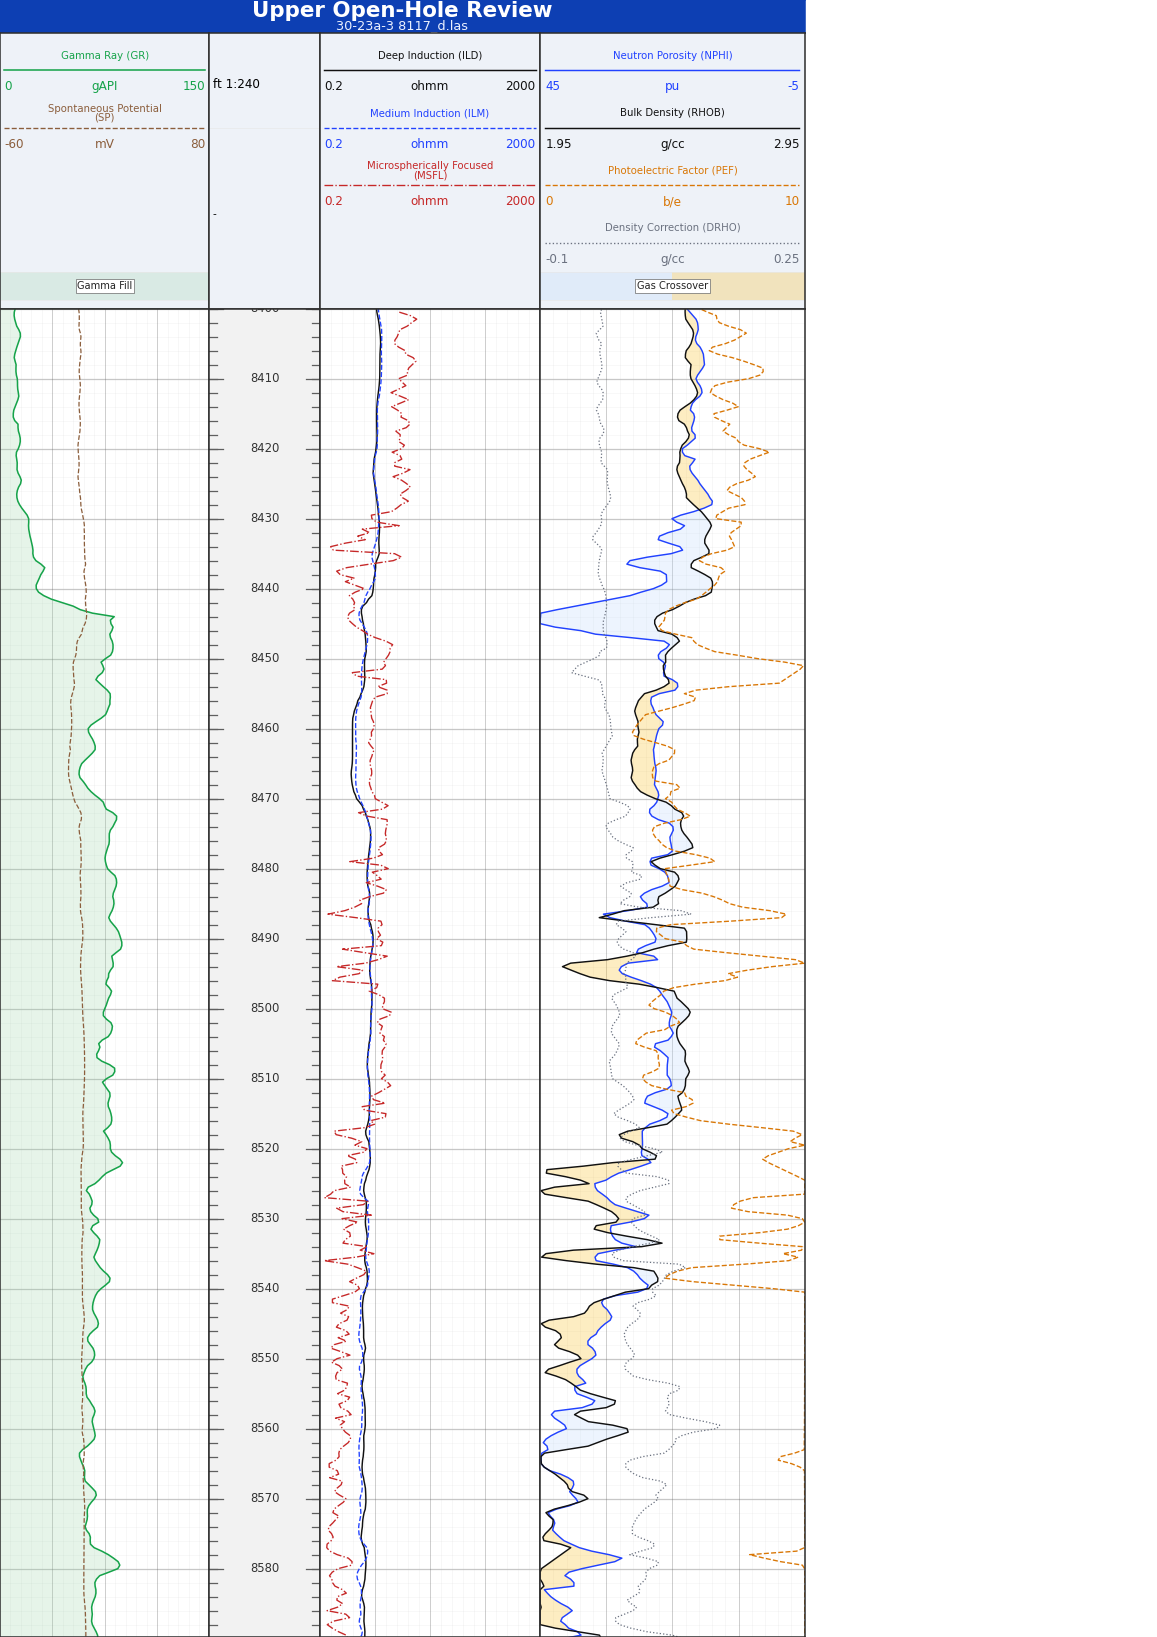

In [9]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_3_add_porosity_fill_logfile_path)
result = render_from_logfile(step_3_add_porosity_fill_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## Step 4. Finish the packet with a second depth window

Reuse the same template and same LAS source, but add a second section so the packet covers both the upper and lower review intervals.

What this step teaches:

- Reusing the template keeps report styling and headings consistent while the logfile adds a second interpretation window.
- The public-data and IP remarks belong in the final production packet, not only in the README.
- Only duplicate a section after the first one is correct; otherwise you duplicate mistakes and double the cleanup.


In [10]:
step_4_final_two_window_packet_logfile_path = tutorial_dir / "step_4_final_two_window_packet.log.yaml"
step_4_final_two_window_packet_logfile_text = '''
template:
  path: ./base.template.yaml
version: 1
name: Porosity tutorial step 4 - final two-window packet
render:
  output_path: ./renders/step_4_final_two_window_packet.pdf
document:
  layout:
    remarks:
    - title: Supported Reconstruction Scope
      lines:
      - This production example builds a two-window open-hole density-neutron review
        from the public LAS source.
      - Heading and report metadata are resolved directly from the LAS well header
        for repeatable packet generation.
      - Only curves present in the source file are plotted; vendor-only packet pages
        are intentionally omitted.
      alignment: left
    - title: Data Source and Coverage
      lines:
      - 'Source file: workspace/data/30-23a-3 8117_d.las'
      - 'Displayed intervals: 8400 to 9300 ft and 9300 to 10200 ft at 1:240 scale.'
      - 'Curves shown: GR, SP, ILD, ILM, MSFL, NPHI, RHOB, PEF, and DRHO.'
      alignment: left
    - title: Interpretation Notes
      lines:
      - Resistivity is shown as deep, medium, and flushed-zone overlays for quick
        invasion review.
      - The porosity track pairs RHOB and NPHI with gas-crossover fill support plus
        PEF and DRHO QC curves.
      - Use this packet as a reproducible demonstration layout, not as a certified
        vendor log replacement.
      alignment: left
    - title: Public Data and IP Notice
      lines:
      - This example uses publicly available or repository-provided demonstration
        data intended for educational use.
      - Rendered layouts are independent reproductions generated by wellplot, not
        vendor-authored originals or official service-company deliverables.
      - Original trademarks and service names remain the property of their respective
        owners.
      - Confirm data provenance and redistribution rights before reusing outputs outside
        this repository.
      alignment: left
    log_sections:
    - id: upper_review
      title: Upper Open-Hole Review
      subtitle: 30-23a-3 8117_d.las
      depth_range:
      - 8400
      - 9300
      data:
        source_path: ../../data/30-23a-3 8117_d.las
        source_format: las
      tracks:
      - id: gr_sp
        title: ''
        kind: normal
        width_mm: 38
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 20
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: resistivity
        title: ''
        kind: normal
        width_mm: 40
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: porosity
        title: ''
        kind: normal
        width_mm: 48
        position: 4
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 5
          - kind: divisions
            enabled: false
            reserve_space: false
    - id: lower_review
      title: Lower Open-Hole Review
      subtitle: 30-23a-3 8117_d.las
      depth_range:
      - 9300
      - 10200
      data:
        source_path: ../../data/30-23a-3 8117_d.las
        source_format: las
      tracks:
      - id: gr_sp
        title: ''
        kind: normal
        width_mm: 38
        position: 1
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: depth
        title: ''
        kind: reference
        width_mm: 20
        position: 2
        reference:
          axis: depth
          define_layout: true
          unit: ft
          scale_ratio: 240
          major_step: 10
          secondary_grid:
            display: true
            line_count: 5
          header:
            display_unit: true
            display_scale: true
            display_annotations: false
          number_format:
            format: automatic
            precision: 0
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 2
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: resistivity
        title: ''
        kind: normal
        width_mm: 40
        position: 3
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 3
          - kind: divisions
            enabled: false
            reserve_space: false
      - id: porosity
        title: ''
        kind: normal
        width_mm: 48
        position: 4
        grid:
          vertical:
            main:
              scale: linear
              line_count: 4
              spacing_mode: count
            secondary:
              scale: linear
              line_count: 5
              spacing_mode: count
        track_header:
          objects:
          - kind: title
            enabled: false
            reserve_space: false
          - kind: scale
            enabled: true
            line_units: 1
          - kind: legend
            enabled: true
            line_units: 5
          - kind: divisions
            enabled: false
            reserve_space: false
  bindings:
    channels:
    - section: upper_review
      channel: GR
      track_id: gr_sp
      kind: curve
      label: Gamma Ray (GR)
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
      fill:
        kind: to_lower_limit
        label: Gamma Fill
        color: '#8fd19e'
        alpha: 0.22
    - section: upper_review
      channel: SP
      track_id: gr_sp
      kind: curve
      label: Spontaneous Potential (SP)
      header_display:
        wrap_name: true
      style:
        color: '#8b5e3c'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: -60
        max: 80
    - section: upper_review
      channel: ILD
      track_id: resistivity
      kind: curve
      label: Deep Induction (ILD)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: ILM
      track_id: resistivity
      kind: curve
      label: Medium Induction (ILM)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.7
        line_style: --
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: MSFL
      track_id: resistivity
      kind: curve
      label: Microspherically Focused (MSFL)
      header_display:
        wrap_name: true
      style:
        color: '#c62828'
        line_width: 0.7
        line_style: -.
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: upper_review
      channel: NPHI
      track_id: porosity
      kind: curve
      id: nphi_overlay
      label: Neutron Porosity (NPHI)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: -5
        max: 45
        reverse: true
      fill:
        kind: between_instances
        other_element_id: rhob_overlay
        label: Gas Crossover
        color: '#d1d5db'
        alpha: 0.18
        crossover:
          enabled: true
          left_color: '#bfdbfe'
          right_color: '#fbbf24'
          alpha: 0.28
    - section: upper_review
      channel: RHOB
      track_id: porosity
      kind: curve
      id: rhob_overlay
      label: Bulk Density (RHOB)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 1.95
        max: 2.95
    - section: upper_review
      channel: PEF
      track_id: porosity
      kind: curve
      label: Photoelectric Factor (PEF)
      header_display:
        wrap_name: true
      style:
        color: '#d97706'
        line_width: 0.7
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
    - section: upper_review
      channel: DRHO
      track_id: porosity
      kind: curve
      label: Density Correction (DRHO)
      header_display:
        wrap_name: true
      style:
        color: '#6b7280'
        line_width: 0.65
        line_style: ':'
      scale:
        kind: linear
        min: -0.1
        max: 0.25
    - section: lower_review
      channel: GR
      track_id: gr_sp
      kind: curve
      label: Gamma Ray (GR)
      header_display:
        wrap_name: true
      style:
        color: '#16a34a'
        line_width: 0.8
      scale:
        kind: linear
        min: 0
        max: 150
      fill:
        kind: to_lower_limit
        label: Gamma Fill
        color: '#8fd19e'
        alpha: 0.22
    - section: lower_review
      channel: SP
      track_id: gr_sp
      kind: curve
      label: Spontaneous Potential (SP)
      header_display:
        wrap_name: true
      style:
        color: '#8b5e3c'
        line_width: 0.65
        line_style: --
      scale:
        kind: linear
        min: -60
        max: 80
    - section: lower_review
      channel: ILD
      track_id: resistivity
      kind: curve
      label: Deep Induction (ILD)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: lower_review
      channel: ILM
      track_id: resistivity
      kind: curve
      label: Medium Induction (ILM)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.7
        line_style: --
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: lower_review
      channel: MSFL
      track_id: resistivity
      kind: curve
      label: Microspherically Focused (MSFL)
      header_display:
        wrap_name: true
      style:
        color: '#c62828'
        line_width: 0.7
        line_style: -.
      scale:
        kind: log
        min: 0.2
        max: 2000
    - section: lower_review
      channel: NPHI
      track_id: porosity
      kind: curve
      id: nphi_overlay
      label: Neutron Porosity (NPHI)
      header_display:
        wrap_name: true
      style:
        color: '#2142ff'
        line_width: 0.75
      scale:
        kind: linear
        min: -5
        max: 45
        reverse: true
      fill:
        kind: between_instances
        other_element_id: rhob_overlay
        label: Gas Crossover
        color: '#d1d5db'
        alpha: 0.18
        crossover:
          enabled: true
          left_color: '#bfdbfe'
          right_color: '#fbbf24'
          alpha: 0.28
    - section: lower_review
      channel: RHOB
      track_id: porosity
      kind: curve
      id: rhob_overlay
      label: Bulk Density (RHOB)
      header_display:
        wrap_name: true
      style:
        color: '#111111'
        line_width: 0.75
      scale:
        kind: linear
        min: 1.95
        max: 2.95
    - section: lower_review
      channel: PEF
      track_id: porosity
      kind: curve
      label: Photoelectric Factor (PEF)
      header_display:
        wrap_name: true
      style:
        color: '#d97706'
        line_width: 0.7
        line_style: --
      scale:
        kind: linear
        min: 0
        max: 10
    - section: lower_review
      channel: DRHO
      track_id: porosity
      kind: curve
      label: Density Correction (DRHO)
      header_display:
        wrap_name: true
      style:
        color: '#6b7280'
        line_width: 0.65
        line_style: ':'
      scale:
        kind: linear
        min: -0.1
        max: 0.25
'''
step_4_final_two_window_packet_logfile_path.write_text(step_4_final_two_window_packet_logfile_text)

print("Wrote:", step_4_final_two_window_packet_logfile_path.relative_to(REPO_ROOT))


Wrote: workspace/tutorials/forge16b_porosity_example/step_4_final_two_window_packet.log.yaml


Validated: Porosity tutorial step 4 - final two-window packet
Pages created: 12
PDF written to: workspace/tutorials/forge16b_porosity_example/renders/step_4_final_two_window_packet.pdf


### Opening page of the final tutorial packet

The final packet keeps the reusable template and adds production remarks suitable for a public example.

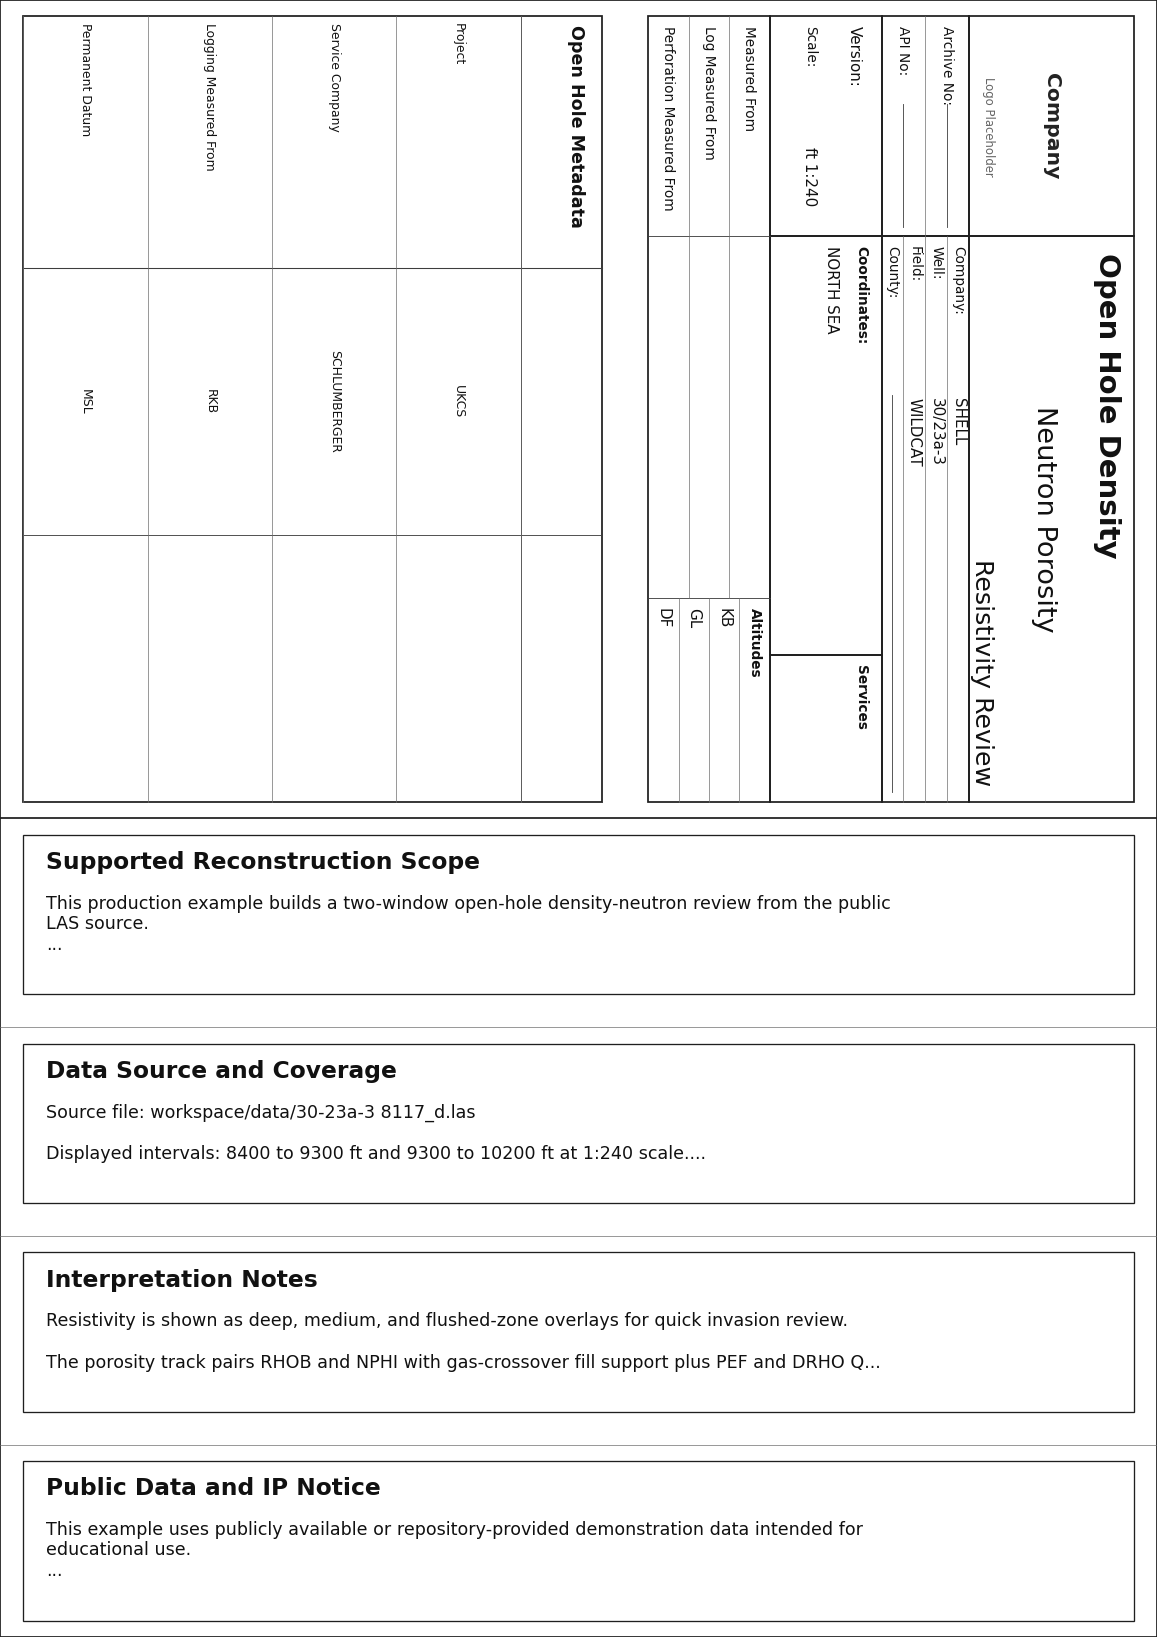

### Lower review section

The same LAS source is reused over a second depth window so the packet can extend deeper without changing the template.

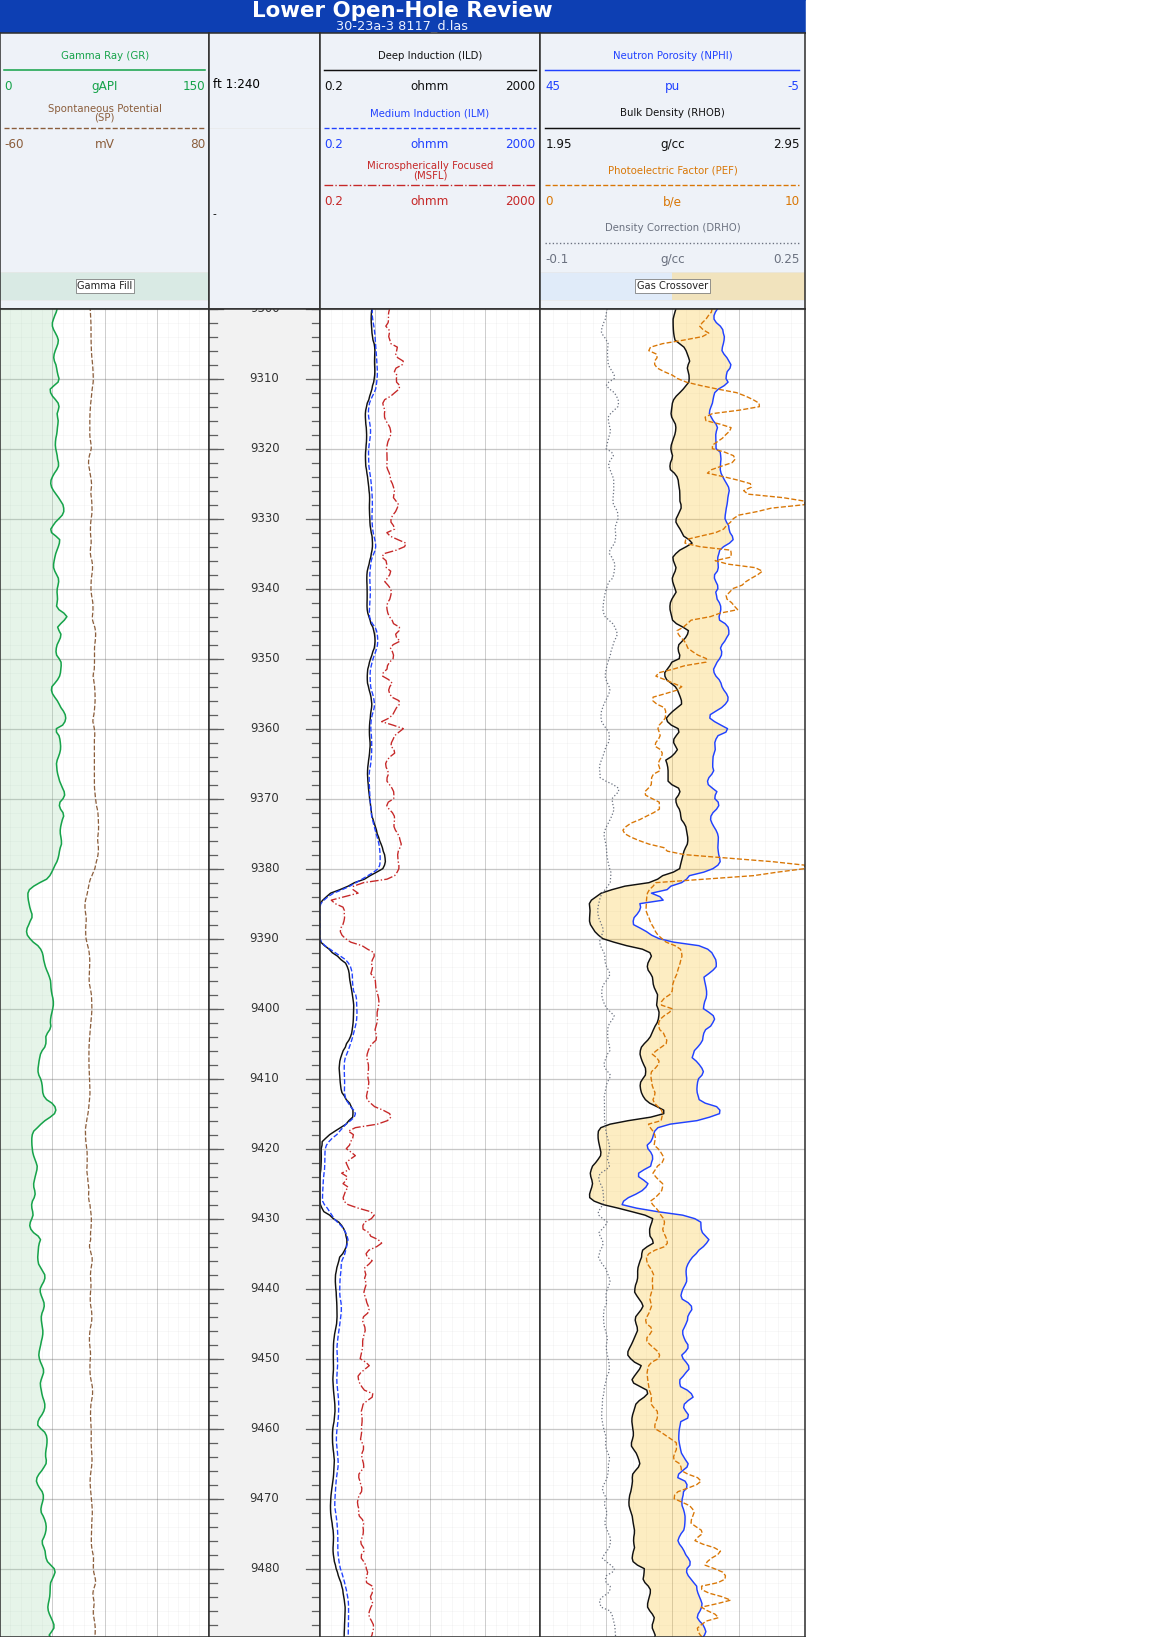

In [11]:
from wellplot import load_logfile, render_from_logfile

spec = load_logfile(step_4_final_two_window_packet_logfile_path)
result = render_from_logfile(step_4_final_two_window_packet_logfile_path)

print("Validated:", spec.name)
print("Pages created:", result.page_count)
print("PDF written to:", result.output_path.relative_to(REPO_ROOT))


## How To Adapt This Tutorial To Your Own Well

- Copy the template first if your page style and heading layout will be reused across wells.
- Point the logfile at your own LAS file and list only the curves that actually exist in that source.
- Tune one section until it looks right before you add extra windows, extra tracks, or extra fills.
- Keep the public-data and IP notice explicit whenever the source data is public or redistributed for demonstration purposes.

## When To Open The Developer Notebook

- use the developer notebook only when you want the raw repository example internals, full source dumps, or lower-level implementation details
- developer reference notebook: `examples/notebooks/developer/forge16b_porosity_example.ipynb`
